In [1]:
# pip install numpy librosa soundfile

In [1]:
import librosa
import numpy as np
import os
import soundfile as sf
import sys
from collections import Counter

In [2]:
emotion_map = {
    'ANG': 'anger',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

In [3]:
crema_dataset_path = 'D:\Bhumika\College_Project\Data\AudioWAV'
processed_data_path = 'D:\Bhumika\College_Project\Data\Processed_data'

In [4]:
def preprocess_audio(file_path, target_sr=16000):
    """
    Loads, cleans, and extracts MFCC features from an audio file.
    """
    try:
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Resample to 16kHz if necessary
        if sr != target_sr:
            y = librosa.resample(y=y, orig_sr=sr, target_sr=target_sr)
        
        # Convert to mono
        if y.ndim > 1:
            y = librosa.to_mono(y)
        
        # Trim leading/trailing silence (adjust top_db for sensitivity)
        y, _ = librosa.effects.trim(y, top_db=25)
        
        # Normalize volume
        y = librosa.util.normalize(y)
        
        # Extract MFCC features
        # n_mfcc is the number of coefficients to return
        mfccs = librosa.feature.mfcc(y=y, sr=target_sr, n_mfcc=40)
        delta = librosa.feature.delta(mfccs)
        delta2 = librosa.feature.delta(mfccs, order=2)

        mfccs = np.vstack([mfccs, delta, delta2]).astype(np.float32)
        # To ensure features have a consistent length, we might pad or truncate them.
        # For now, we will return the features as is.
        
        return y, mfccs

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None


In [5]:
def process_dataset(source_dir, save_dir):
    """
    Loops through the source directory, processes each WAV file,
    and saves the cleaned, padded features.
    """
    audio_save_dir = os.path.join(save_dir, 'audio')
    features_save_dir = os.path.join(save_dir, 'features')

    os.makedirs(audio_save_dir, exist_ok=True)
    os.makedirs(features_save_dir, exist_ok=True)

    features_list = []
    labels_list = []
    ids_list = []

    print(f"Starting processing of {source_dir}...")
    
    # Get a list of all .wav files
    file_list = [f for f in os.listdir(source_dir) if f.endswith('.wav')]
    total_files = len(file_list)


    for i, filename in enumerate(file_list):
        if (i + 1) % 100 == 0:
            print(f"Processing file {i + 1}/{total_files}: {filename}")
        
        source_path = os.path.join(source_dir, filename)
            
        parts = filename.split('_')
        if len(parts) < 3:
            print(f"Skipping {filename}: unexpected format.")
            continue
        emotion_code = parts[2]
        if emotion_code not in emotion_map:
            print(f"Skipping {filename}: unknown emotion code {emotion_code}.")
            continue

        emotion_label = emotion_map[emotion_code]

        # The key is the filename without the .wav extension
        filename_key = filename.split('.')[0] # e.g., "1001_TSI_HAP_XX"
        
        cleaned_audio, mfccs = preprocess_audio(source_path)
            
        if cleaned_audio is not None and mfccs is not None:
                save_audio_path = os.path.join(audio_save_dir, filename)
                sf.write(save_audio_path, cleaned_audio, 16000)

                features_list.append(mfccs)
                labels_list.append(emotion_label)
                ids_list.append(filename_key)

                

    print(f"\nProcessing complete. Processed {len(features_list)} files.")
    print("Padding features to uniform length...")

    # 1. Find the maximum length of all feature arrays
    max_len = max(feature.shape[1] for feature in features_list)

    print(f"Max feature length (time steps): {max_len}")
          
    # 2. Create a new list for padded features
    padded_features_list = []
    
    # 3. Pad each feature array to the max_len
    for feature in features_list:
        # Create a new array of zeros with the target shape
        padded_feature = np.zeros((feature.shape[0], max_len), dtype=np.float32)
        # Copy the original feature data into the new array
        padded_feature[:, :feature.shape[1]] = feature
        padded_features_list.append(padded_feature)

    # Convert the list of padded features to a single NumPy array
    final_features_array = np.array(padded_features_list,dtype=np.float32)
    final_labels_array = np.array(labels_list)
    final_ids_array = np.array(ids_list)
    

    print("\n--- Final Data Shapes ---")
    print(f"Features array shape: {final_features_array.shape}")
    print(f"Labels array shape:   {final_labels_array.shape}")
    print(f"IDs array shape:      {final_ids_array.shape}")
    
    # --- NEW: Save as a single, compressed .npz file ---
    # This is much better than multiple .npy files
    save_path = os.path.join(save_dir, 'aligned_speech_data.npz')
    np.savez_compressed(
        save_path,
        features=final_features_array,
        labels=final_labels_array,
        ids=final_ids_array
    )
    
    print(f"\nSuccessfully saved aligned data to:\n{save_path}")


In [6]:
if __name__ == '__main__':
    
    # Check if paths exist
    if not os.path.isdir(crema_dataset_path):
        print(f"Error: Source directory not found:\n{crema_dataset_path}")
        print("Please update the 'crema_dataset_path' variable in the script.")
        sys.exit(1)
        
    if not os.path.isdir(processed_data_path):
        print(f"Warning: Save directory not found. Creating it at:\n{processed_data_path}")
        os.makedirs(processed_data_path)

    # Run the main processing function
    process_dataset(crema_dataset_path, processed_data_path)


Starting processing of D:\Bhumika\College_Project\Data\AudioWAV...
Processing file 100/7442: 1002_IEO_HAP_MD.wav
Processing file 200/7442: 1003_ITS_FEA_XX.wav
Processing file 300/7442: 1004_MTI_FEA_XX.wav
Processing file 400/7442: 1005_TSI_FEA_XX.wav
Processing file 500/7442: 1007_IEO_ANG_MD.wav
Processing file 600/7442: 1008_IOM_NEU_XX.wav
Processing file 700/7442: 1009_IWW_NEU_XX.wav
Processing file 800/7442: 1010_TSI_NEU_XX.wav
Processing file 900/7442: 1012_IEO_DIS_LO.wav
Processing file 1000/7442: 1013_ITH_ANG_XX.wav
Processing file 1100/7442: 1014_IWW_ANG_XX.wav
Processing file 1200/7442: 1015_TIE_ANG_XX.wav
Processing file 1300/7442: 1017_DFA_ANG_XX.wav
Processing file 1400/7442: 1018_IEO_NEU_XX.wav
Processing file 1500/7442: 1019_IWL_FEA_XX.wav
Processing file 1600/7442: 1020_TAI_FEA_XX.wav
Processing file 1700/7442: 1021_WSI_FEA_XX.wav
Processing file 1800/7442: 1023_IEO_FEA_MD.wav
Processing file 1900/7442: 1024_ITH_NEU_XX.wav
Processing file 2000/7442: 1025_IWW_NEU_XX.wav
Pr

Verification

In [7]:
def verify_data(npz_file_path):
    """
    Loads the .npz file and prints a summary to verify alignment.
    """
    
    if not os.path.exists(npz_file_path):
        print(f"Error: File not found at {npz_file_path}")
        print("Please run 'create_aligned_dataset.py' first.")
        return

    print(f"Loading data from {npz_file_path}...")
    
    # Load the compressed .npz file
    # data acts like a dictionary
    data = np.load(npz_file_path)
    
    # Extract the arrays using their names
    features = data['features']
    labels = data['labels']
    ids = data['ids']
    
    print("\n--- Verification Summary ---")
    print(f"Total samples found: {len(ids)}")
    print(f"Features array shape: {features.shape}")
    print(f"Labels array shape:   {labels.shape}")
    print(f"IDs array shape:      {ids.shape}")
    
    print("\n--- Example Data (from Index 10) ---")
    
    # Get data from a sample index (e.g., index 10)
    sample_id = ids[10]
    sample_label = labels[10]
    sample_feature = features[10]
    
    print(f"ID:     {sample_id}")
    print(f"Label:  {sample_label}")
    print(f"Feature Shape: {sample_feature.shape}")
    
    print("\n--- Alignment Check ---")
    print(f"This shows that the feature data at index 10 belongs to the")
    print(f"audio file '{sample_id}.wav' and has the emotion '{sample_label}'.")
    print("The system is now aligned!")
    
    # You can also find a specific file
    try:
        target_id = '1001_TSI_HAP_XX'
        # Find the index corresponding to a specific ID
        index = np.where(ids == target_id)[0][0]
        
        print(f"\n--- Lookup Test ---")
        print(f"Looking for ID: '{target_id}'")
        print(f"Found at index: {index}")
        print(f"Its label is:   {labels[index]}")
        
    except IndexError:
        print(f"\nCould not find test ID '1001_TSI_HAP_XX' in the dataset.")
    except Exception as e:
        print(f"\nAn error occurred during lookup test: {e}")

if __name__ == '__main__':
    # SET THIS to the location where you saved your .npz file
    save_dir = 'D:/Bhumika/College_Project/Data/Processed_data'
    
    file_path = os.path.join(save_dir, 'aligned_speech_data.npz')
    
    verify_data(file_path)


Loading data from D:/Bhumika/College_Project/Data/Processed_data\aligned_speech_data.npz...

--- Verification Summary ---
Total samples found: 7442
Features array shape: (7442, 120, 157)
Labels array shape:   (7442,)
IDs array shape:      (7442,)

--- Example Data (from Index 10) ---
ID:     1001_IEO_DIS_LO
Label:  disgust
Feature Shape: (120, 157)

--- Alignment Check ---
This shows that the feature data at index 10 belongs to the
audio file '1001_IEO_DIS_LO.wav' and has the emotion 'disgust'.
The system is now aligned!

--- Lookup Test ---
Looking for ID: '1001_TSI_HAP_XX'
Found at index: 73
Its label is:   happy


## Analyze the Emotion Distribution

We need to see how balanced our dataset is. Are there an equal number of samples for each emotion? An imbalanced dataset can bias our model.

This script will load the labels and plot a bar chart showing the number of clips for each emotion.

The CREMA-D dataset is fairly balanced, so we should see similar bar heights for all emotions. If one bar were dramatically smaller, we would need to consider that when training your model.

Counter({np.str_('anger'): 1271, np.str_('disgust'): 1271, np.str_('fear'): 1271, np.str_('happy'): 1271, np.str_('sad'): 1271, np.str_('neutral'): 1087})


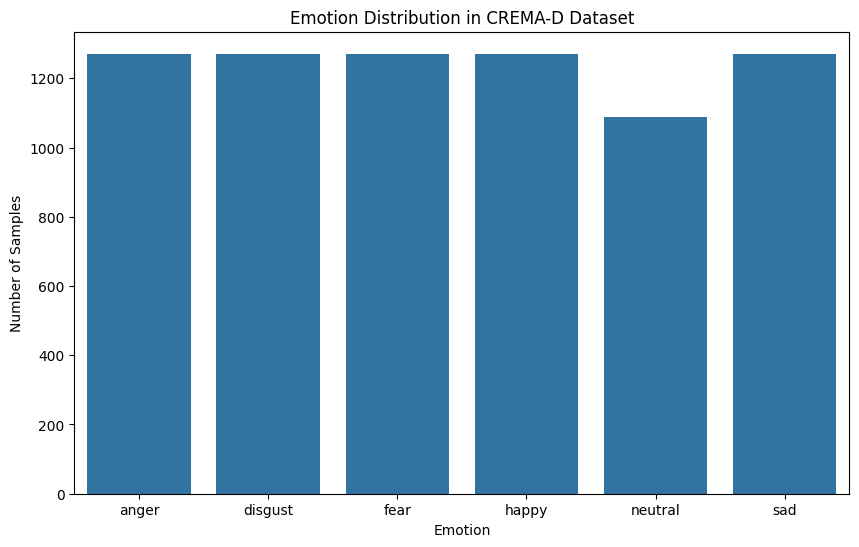

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- Load your saved labels ---
processed_data_path = 'D:\Bhumika\College_Project\Data\Processed_data'
labels_path = f'{processed_data_path}/features/all_labels.npy'
labels = np.load(labels_path, allow_pickle=True)

# --- Count the occurrences of each emotion ---
label_counts = Counter(labels)
print(label_counts)

# --- Plot the distribution ---
plt.figure(figsize=(10, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title('Emotion Distribution in CREMA-D Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.show()

## Visualize the MFCC Features

 Do MFCCs for "happy" look different from "sad"? Visualizing them can give an intuition for how the model will distinguish between them.

C:\Users\bhumi\AppData\Local\Temp\ipykernel_19884\921996786.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


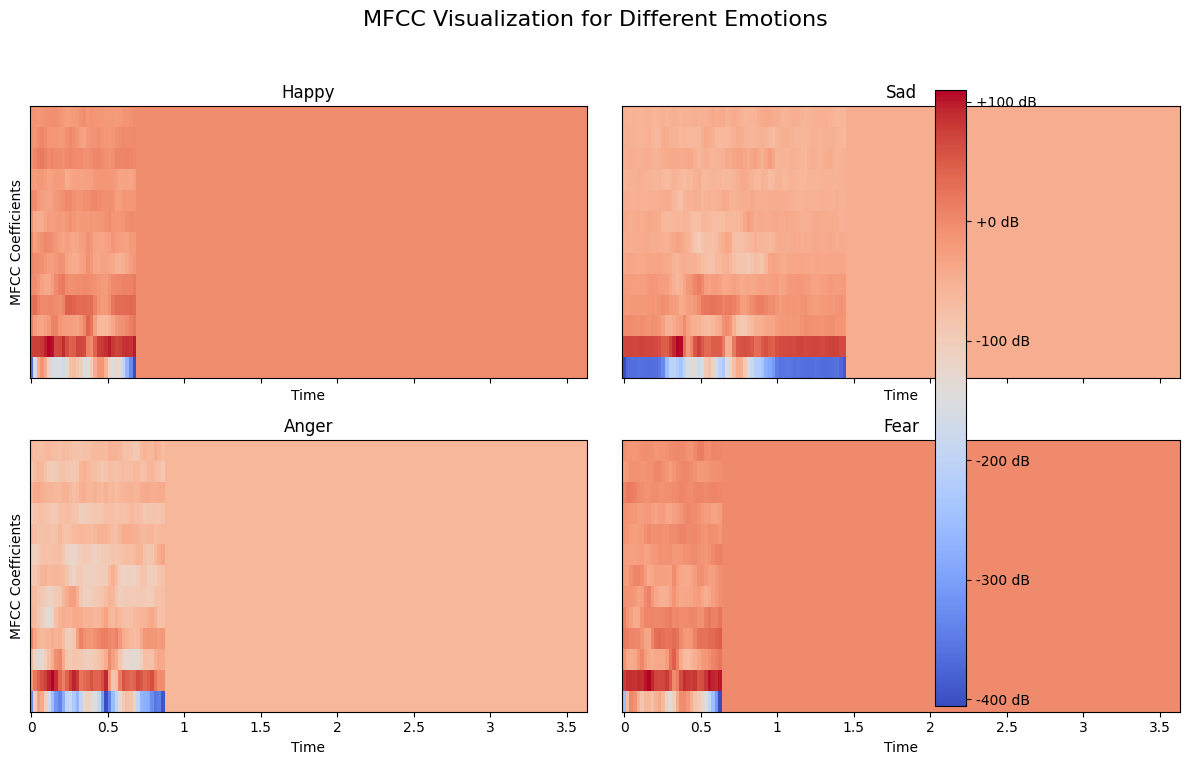

In [9]:
import librosa.display

# --- Load your saved features and labels ---
features_path = f'{processed_data_path}/features/all_features.npy'
features = np.load(features_path, allow_pickle=True)
labels = np.load(labels_path, allow_pickle=True)

# --- Function to find the first index of an emotion ---
def get_index_for_emotion(emotion_label):
    return np.where(labels == emotion_label)[0][0]

# --- Emotions you want to visualize ---
emotions_to_plot = ['happy', 'sad', 'anger', 'fear']
indices = {emotion: get_index_for_emotion(emotion) for emotion in emotions_to_plot}

# --- Create plots ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharey=True, sharex=True)
fig.suptitle('MFCC Visualization for Different Emotions', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, emotion in enumerate(emotions_to_plot):
    idx = indices[emotion]
    mfcc_data = features[idx]
    
    img = librosa.display.specshow(mfcc_data, x_axis='time', ax=axes[i])
    axes[i].set_title(emotion.capitalize())
    axes[i].set_xlabel('Time')
    if i % 2 == 0:
        axes[i].set_ylabel('MFCC Coefficients')

fig.colorbar(img, ax=axes, format='%+2.0f dB')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()